In [1]:
import os
os.environ['VXM_BACKEND'] = 'pytorch'
import os, sys

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn import Sequential
import torch.optim as optim

import voxelmorph as vxm
import neurite as ne
import scipy.ndimage



In [2]:
os.environ.get('VXM_BACKEND')

'pytorch'

In [3]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cuda:0


# a.pth に保存されたモデルを読み込み、固定x方向シフトで評価する
# このセルは学習を再開せず、評価画像とCSVだけを作成する。
import csv
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

checkpoint_path = Path('a.pth')
if not checkpoint_path.exists():
    raise FileNotFoundError(f'a.pth が見つかりません: {checkpoint_path.resolve()}')

# a.pth は state_dict のみを保存しているため、同じモデル構造を作成して読み込む。
evaluation_model = vxm.networks.VxmDense((64, 128, 128), nb_features, int_steps=0).to(device)
evaluation_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
evaluation_model.eval()

evaluation_moving = torch.from_numpy(x_train[0:1]).unsqueeze(1).to(device, dtype=torch.float32)
evaluation_shifts = [-40, -30, -20, -10, 0, 10, 20, 30, 40]
evaluation_dir = Path('a_checkpoint_evaluation')
evaluation_dir.mkdir(exist_ok=True)
slice_index = evaluation_moving.shape[2] // 2
moving_np = evaluation_moving[0, 0, slice_index].detach().cpu().numpy()
vmin, vmax = np.percentile(moving_np, [1, 99])
rows = []

with torch.no_grad():
    fig, axes = plt.subplots(len(evaluation_shifts), 4, figsize=(16, 3.5 * len(evaluation_shifts)), constrained_layout=True)
    for row_index, shift in enumerate(evaluation_shifts):
        true_flow = torch.zeros((1, 3, *evaluation_moving.shape[2:]), device=device)
        true_flow[:, 2] = float(shift)
        target = transformer(evaluation_moving, true_flow)
        moved, predicted_flow = evaluation_model(evaluation_moving, target)
        rmse_before = torch.sqrt(torch.mean((target - evaluation_moving) ** 2)).item()
        rmse_after = torch.sqrt(torch.mean((target - moved) ** 2)).item()
        dvf_rmse = torch.sqrt(torch.mean((true_flow - predicted_flow) ** 2)).item()
        predicted_x_mean = predicted_flow[:, 2].mean().item()
        rows.append({'checkpoint': str(checkpoint_path), 'shift_pixels_x': shift, 'rmse_before': rmse_before, 'rmse_after': rmse_after, 'dvf_rmse': dvf_rmse, 'predicted_flow_x_mean': predicted_x_mean})

        for column, (image, title) in enumerate([
            (evaluation_moving, 'Moving'),
            (target, f"Moving′\nx shift={shift}px"),
            (moved, f"Moved\nRMSE={rmse_after:.5f}"),
        ]):
            axes[row_index, column].imshow(image[0, 0, slice_index].detach().cpu(), cmap='gray', vmin=vmin, vmax=vmax)
            axes[row_index, column].set_title(title)
            axes[row_index, column].axis('off')

        flow_image = axes[row_index, 3].imshow(predicted_flow[0, 2, slice_index].detach().cpu(), cmap='jet')
        axes[row_index, 3].set_title(f'Predicted DVF x\nmean={predicted_x_mean:.3f}, RMSE={dvf_rmse:.3f}')
        axes[row_index, 3].axis('off')
        fig.colorbar(flow_image, ax=axes[row_index, 3], fraction=0.046, pad=0.04)

    fig.suptitle('a.pth checkpoint evaluation', fontsize=16)
    figure_path = evaluation_dir / 'a_known_x_shifts.png'
    fig.savefig(figure_path, dpi=180, bbox_inches='tight')
    plt.show()
    plt.close(fig)

csv_path = evaluation_dir / 'a_known_x_shift_metrics.csv'
with csv_path.open('w', newline='', encoding='utf-8') as file:
    writer = csv.DictWriter(file, fieldnames=rows[0].keys())
    writer.writeheader()
    writer.writerows(rows)

print(f'評価画像: {figure_path.resolve()}')
print(f'評価CSV: {csv_path.resolve()}')


In [4]:
# 画像を読み込み（ノートブックをSaitoまたはyamatoCodeから実行できるようにする）
from pathlib import Path
data_candidates = [
    Path('Data') / 'TrainData_NoBed.npz',
    Path('..') / 'Data' / 'TrainData_NoBed.npz',
]
data_path = next((path for path in data_candidates if path.exists()), None)
if data_path is None:
    searched = '\n'.join(str(path.resolve()) for path in data_candidates)
    raise FileNotFoundError(f'TrainData_NoBed.npz が見つかりません。確認したパス:\n{searched}')
print(f'Loading training data: {data_path.resolve()}')
x_train = np.load(data_path)['Train']
x_train = np.transpose(x_train, (3, 0, 1, 2))

# 新しいボリュームのサイズ (各軸を半分にする)
new_shape = tuple([dim // 2 for dim in x_train.shape[1:]])

# サイズを半分に縮小
x_train_resized = np.zeros((x_train.shape[0], *new_shape))  # 新しい形に合わせて初期化

for i in range(x_train.shape[0]):
    # 各画像を縮小
    x_train_resized[i] = scipy.ndimage.zoom(x_train[i], (0.5, 0.5, 0.5), order=3)
print('Resized train vol_shape:', x_train_resized.shape[1:])
print('Resized train shape:', x_train_resized.shape)
x_train = x_train_resized

Resized train vol_shape: (64, 128, 128)
Resized train shape: (400, 64, 128, 128)


In [5]:
import torch

def vxm_data_generator(x_data, batch_size):
    vol_shape = x_data.shape[1:]  # データ形状を取得
    ndims = len(vol_shape)
    
    zero_phi = np.zeros([batch_size, *vol_shape, ndims])
    
    while True:
        idx1 = np.random.randint(0, x_data.shape[0], size=batch_size)
        moving_images = x_data[idx1, ..., np.newaxis]
        idx2 = np.random.randint(0, x_data.shape[0], size=batch_size)
        fixed_images = x_data[idx2, ..., np.newaxis]

        # TensorFlowからPyTorchのデータ形式に変換
        moving_images = torch.tensor(moving_images).permute(0, 4, 1, 2, 3).float()
        fixed_images = torch.tensor(fixed_images).permute(0, 4, 1, 2, 3).float()

        # チャンネルを最初の次元に追加
        moving_images = moving_images.permute(0, 1, 2, 3, 4)  # チャンネルを最初の次元に移動
        fixed_images = fixed_images.permute(0, 1, 2, 3, 4)  # チャンネルを最初の次元に移動

        inputs = [moving_images, fixed_images]
        outputs = [fixed_images, zero_phi]

        yield (inputs, outputs)

In [6]:
train_generator = vxm_data_generator(x_train, batch_size=2)
in_sample, out_sample = next(train_generator)

# in_sampleとout_sampleの内容を確認する
print("Input Sample Shapes:")
print("Moving Images Shape:", in_sample[0].shape)
print("Fixed Images Shape:", in_sample[1].shape)

print("\nOutput Sample Shapes:")
print("Moved Images (Fixed) Shape:", out_sample[0].shape)
print("Zero Gradient Shape:", out_sample[1].shape)

Input Sample Shapes:
Moving Images Shape: torch.Size([2, 1, 64, 128, 128])
Fixed Images Shape: torch.Size([2, 1, 64, 128, 128])

Output Sample Shapes:
Moved Images (Fixed) Shape: torch.Size([2, 1, 64, 128, 128])
Zero Gradient Shape: (2, 64, 128, 128, 3)


In [7]:
mse_loss = vxm.losses.MSE().loss
grad_loss = vxm.losses.Grad('l2').loss

def total_loss(y_true, y_pred):
    mse = mse_loss(y_true, y_pred)
    grad = grad_loss(y_true, y_pred)
    return mse + 0.01 * grad, mse, grad
#     return mse_loss(y_true, y_pred)

def MSE_Loss(y_true, y_pred):
    mse = mse_loss(y_true, y_pred)
    return mse

def lncc_loss(I, J, window=9, eps=1e-5):
    # I, J: (B, 1, D, H, W)
    padding = window // 2
    weight = torch.ones(1, 1, window, window, window, device=I.device)

    I2 = I * I
    J2 = J * J
    IJ = I * J

    I_sum = F.conv3d(I, weight, padding=padding)
    J_sum = F.conv3d(J, weight, padding=padding)
    I2_sum = F.conv3d(I2, weight, padding=padding)
    J2_sum = F.conv3d(J2, weight, padding=padding)
    IJ_sum = F.conv3d(IJ, weight, padding=padding)

    win_size = window ** 3
    u_I = I_sum / win_size
    u_J = J_sum / win_size

    cross = IJ_sum - u_J * I_sum - u_I * J_sum + u_I * u_J * win_size
    I_var = I2_sum - 2 * u_I * I_sum + u_I * u_I * win_size
    J_var = J2_sum - 2 * u_J * J_sum + u_J * u_J * win_size

    lncc = cross * cross / (I_var * J_var + eps)
    return -torch.mean(lncc)  # maximize LNCC → minimize -LNCC

In [8]:
# configure unet input shape (concatenation of moving and fixed images)
ndim = 3
unet_input_features = 2
# inshape = (*x_train.shape[1:], unet_input_features)

nb_features = [
    [32, 64, 64, 64, 64],
    [64, 64, 64, 64, 64, 32, 16, 16]
]


In [10]:
model3D = vxm.networks.VxmDense((64, 128, 128), nb_features, int_steps=0)
model3D.to(device)
optimizer = optim.Adam(model3D.parameters(), lr=1e-4)

c:\Users\ri0151fv\AppData\Local\anaconda3\envs\vxm310\lib\site-packages\torch\functional.py:534: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\TensorShape.cpp:3596.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


In [11]:
A = 100
B = 0.01

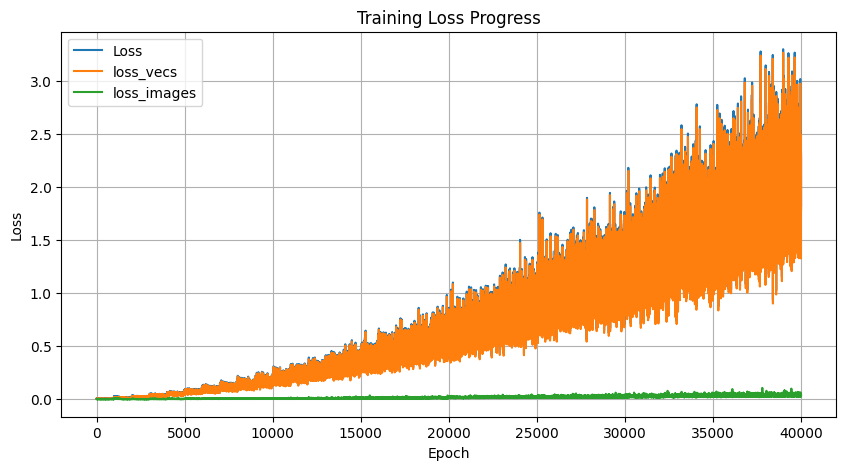

Epoch 39991/40000, Loss: 1.8237, loss_vec: 1.7894, loss_image: 0.0342, Shift Range: ±40 pixels


Epoch 39992/40000, Loss: 1.6444, loss_vec: 1.6002, loss_image: 0.0442, Shift Range: ±40 pixels


Epoch 39993/40000, Loss: 1.6686, loss_vec: 1.6449, loss_image: 0.0236, Shift Range: ±40 pixels


Epoch 39994/40000, Loss: 1.6430, loss_vec: 1.6095, loss_image: 0.0335, Shift Range: ±40 pixels


Epoch 39995/40000, Loss: 1.9780, loss_vec: 1.9479, loss_image: 0.0302, Shift Range: ±40 pixels


...

Epoch 39997/40000, Loss: 1.9776, loss_vec: 1.9428, loss_image: 0.0348, Shift Range: ±40 pixels


Epoch 39998/40000, Loss: 1.7749, loss_vec: 1.7365, loss_image: 0.0385, Shift Range: ±40 pixels


Epoch 39999/40000, Loss: 1.8556, loss_vec: 1.8245, loss_image: 0.0310, Shift Range: ±40 pixels


100%|██████████| 40000/40000 [4:10:02<00:00,  2.67it/s]

Epoch 40000/40000, Loss: 1.8168, loss_vec: 1.7783, loss_image: 0.0385, Shift Range: ±40 pixels


In [13]:
# NotdecoderHight
from tqdm import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt


transformer = vxm.layers.SpatialTransformer((64, 128, 128)).to(device)

# 3D ガウシアンフィルタを適用する関数
def gaussian_smooth_3d(tensor, kernel_size=5, sigma=1.0):
    """ 3D ガウシアンフィルタで displacement field をスムージング """
    # 3D Gaussian Kernel の作成
    from scipy.ndimage import gaussian_filter
    tensor_np = tensor.cpu().numpy()
    smoothed_np = gaussian_filter(tensor_np, sigma=[0, 0, sigma, sigma, sigma])  # チャネル方向にはフィルタ適用しない
    return torch.tensor(smoothed_np, dtype=torch.float32, device=tensor.device)

# ==========================================
# カリキュラム学習の途中評価・保存設定（256版と同じ目的）
# ==========================================
import csv
from pathlib import Path

OBSERVE_EVERY = 1000  # この128版では1,000 epochごとに難易度を上げる
OBSERVE_SHIFTS = [-40, -30, -20, -10, 0, 10, 20, 30, 40]
OBSERVE_RANDOM_SEED = 20260807
OBSERVE_RANDOM_MAX_SHIFT = 40.0
OBSERVE_DIR = Path('curriculum_observation_128model')
CHECKPOINT_DIR = Path('curriculum_checkpoints_128model')
OBSERVE_DIR.mkdir(exist_ok=True)
CHECKPOINT_DIR.mkdir(exist_ok=True)
print(f'評価画像の保存先: {OBSERVE_DIR.resolve()}')
print(f'チェックポイントの保存先: {CHECKPOINT_DIR.resolve()}')

observation_moving = torch.from_numpy(x_train[0:1]).unsqueeze(1).to(device, dtype=torch.float32)

def rmse(reference, prediction):
    return torch.sqrt(torch.mean((reference - prediction) ** 2)).item()

def observe_known_x_shifts(model, epoch):
    """固定患者に一定x方向変位を与え、画像・DVF精度を評価する。"""
    was_training = model.training
    model.eval()
    epoch_dir = OBSERVE_DIR / f'epoch_{epoch:06d}'
    epoch_dir.mkdir(exist_ok=True)
    rows = []
    with torch.no_grad():
        fig, axes = plt.subplots(len(OBSERVE_SHIFTS), 4, figsize=(16, 3.5 * len(OBSERVE_SHIFTS)), constrained_layout=True)
        slice_index = observation_moving.shape[2] // 2
        moving_np = observation_moving[0, 0, slice_index].detach().cpu().numpy()
        vmin, vmax = np.percentile(moving_np, [1, 99])
        for row_index, shift in enumerate(OBSERVE_SHIFTS):
            true_flow = torch.zeros((1, 3, *observation_moving.shape[2:]), device=device)
            true_flow[:, 2] = float(shift)
            target = transformer(observation_moving, true_flow)
            moved, predicted_flow = model(observation_moving, target)
            image_rmse_before = rmse(target, observation_moving)
            image_rmse_after = rmse(target, moved)
            dvf_rmse = rmse(true_flow, predicted_flow)
            predicted_x_mean = predicted_flow[:, 2].mean().item()
            rows.append({'epoch': epoch, 'shift_pixels_x': shift, 'rmse_before': image_rmse_before, 'rmse_after': image_rmse_after, 'dvf_rmse': dvf_rmse, 'predicted_flow_x_mean': predicted_x_mean})
            panels = [observation_moving, target, moved]
            titles = ['Moving', f"Moving′\nx shift={shift}px", f"Moved\nRMSE={image_rmse_after:.5f}"]
            for column, (image, title) in enumerate(zip(panels, titles)):
                axes[row_index, column].imshow(image[0, 0, slice_index].detach().cpu(), cmap='gray', vmin=vmin, vmax=vmax)
                axes[row_index, column].set_title(title)
                axes[row_index, column].axis('off')
            dvf_image = axes[row_index, 3].imshow(predicted_flow[0, 2, slice_index].detach().cpu(), cmap='jet')
            axes[row_index, 3].set_title(f'Predicted DVF x\nmean={predicted_x_mean:.3f}, RMSE={dvf_rmse:.3f}')
            axes[row_index, 3].axis('off')
            fig.colorbar(dvf_image, ax=axes[row_index, 3], fraction=0.046, pad=0.04)
        fig.suptitle(f'Curriculum learning observation — Epoch {epoch}', fontsize=16)
        fig.savefig(epoch_dir / f'known_x_shifts_epoch_{epoch:06d}.png', dpi=180, bbox_inches='tight')
        plt.show()
        plt.close(fig)
    csv_path = OBSERVE_DIR / 'known_x_shift_metrics.csv'
    write_header = not csv_path.exists()
    with csv_path.open('a', newline='', encoding='utf-8') as file:
        writer = csv.DictWriter(file, fieldnames=rows[0].keys())
        if write_header:
            writer.writeheader()
        writer.writerows(rows)
    if was_training:
        model.train()

def observe_random_deformation(model, epoch):
    """固定シードの滑らかなランダムDVFに対して画像・DVF精度を評価する。"""
    was_training = model.training
    model.eval()
    generator = torch.Generator(device='cpu')
    generator.manual_seed(OBSERVE_RANDOM_SEED)
    true_flow = (torch.rand((1, 3, 8, 16, 16), generator=generator) * 2 - 1) * OBSERVE_RANDOM_MAX_SHIFT
    true_flow = gaussian_smooth_3d(true_flow, sigma=2.0)
    true_flow = torch.nn.functional.interpolate(true_flow, size=observation_moving.shape[2:], mode='trilinear', align_corners=False).to(device)
    with torch.no_grad():
        target = transformer(observation_moving, true_flow)
        moved, predicted_flow = model(observation_moving, target)
        result = {'epoch': epoch, 'seed': OBSERVE_RANDOM_SEED, 'max_initial_shift': OBSERVE_RANDOM_MAX_SHIFT, 'rmse_before': rmse(target, observation_moving), 'rmse_after': rmse(target, moved), 'dvf_rmse': rmse(true_flow, predicted_flow)}
    csv_path = OBSERVE_DIR / 'random_deformation_metrics.csv'
    write_header = not csv_path.exists()
    with csv_path.open('a', newline='', encoding='utf-8') as file:
        writer = csv.DictWriter(file, fieldnames=result.keys())
        if write_header:
            writer.writeheader()
        writer.writerow(result)
    if was_training:
        model.train()
    print(f'[Random deformation] Epoch {epoch}: RMSE {result["rmse_before"]:.5f} → {result["rmse_after"]:.5f}, DVF RMSE={result["dvf_rmse"]:.4f}')

# エポック数と最小ロスの設定
epochs = 40000
best_loss = float('inf')
shift_range = 1

# ロスや他のメトリクスを記録するリスト
losses = []
loss_vecs = []
loss_images = []
loss_hightVecs = []
for epoch in tqdm(range(epochs)):
    # 100エポックごとにshift_rangeを増やす
    if epoch % 1000 == 0 and epoch > 0:
        shift_range += 1
        print(f"Epoch {epoch}: Increasing shift range to ±{shift_range} pixels.")

    # 学習データのバッチを取得
    train_batch, _ = next(train_generator)
    moving_images = torch.tensor(train_batch[0], dtype=torch.float32).to(device)

    # 画像サイズを設定
    B, D, H, W = 2, 8, 16, 16  # バッチサイズと画像の次元

    # displacement_field をボクセルごとにランダムに作成
    displacement_field = (torch.rand((B, 3, D, H, W), dtype=torch.float32) * 2 - 1) * shift_range
    displacement_field = displacement_field.to(device)

    # 3D Gaussian Smoothing を適用
    displacement_field = gaussian_smooth_3d(displacement_field, sigma=2.0)
    displacement_field = torch.nn.functional.interpolate(displacement_field, size=(64,128,128), mode='trilinear', align_corners=False)

    # 位置をずらした画像を生成
    moving_images2 = transformer(moving_images, displacement_field)

    # 勾配を初期化
    optimizer.zero_grad()

    # 順伝播
    transformed_image, Vec = model3D(moving_images, moving_images2)

    loss_vec = MSE_Loss(displacement_field, Vec) * B
    loss_image = MSE_Loss(moving_images2, transformed_image) * A
    
    loss = loss_vec + loss_image

    # 逆伝播
    loss.backward()
    optimizer.step()

    # 固定x方向シフト・固定ランダムDVFでの途中評価
    if epoch == 0 or (epoch + 1) % OBSERVE_EVERY == 0 or (epoch + 1) == epochs:
        observe_known_x_shifts(model3D, epoch + 1)
        observe_random_deformation(model3D, epoch + 1)

    # カリキュラム各段階（1,000 epoch）を再開可能な形式で保存
    if (epoch + 1) % OBSERVE_EVERY == 0:
        torch.save(
            {
                'epoch': epoch + 1,
                'shift_range': shift_range,
                'model_state_dict': model3D.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'training_loss': loss.item(),
                'image_loss': loss_image.item(),
                'dvf_loss': loss_vec.item(),
            },
            CHECKPOINT_DIR / f'pretrain_epoch_{epoch + 1:05d}.pth'
        )

    if (epoch + 1) % 100 == 0:
        torch.save(
            model3D.state_dict(),
            f'a.pth'
        )
        

    losses.append(loss.cpu().item())
    loss_vecs.append(loss_vec.cpu().item())
    loss_images.append(loss_image.cpu().item())

    # 100エポックごとにグラフを更新
    if epoch % 10 == 0:
        clear_output(wait=True)  # 出力をリフレッシュ
        plt.figure(figsize=(10,5))
        plt.plot(losses, label='Loss')
        plt.plot(loss_vecs, label='loss_vecs')
        plt.plot(loss_images, label='loss_images')
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training Loss Progress")
        plt.legend()
        plt.grid(True)
        plt.show()
    
    # エポックごとのロスの表示
    print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.4f}, loss_vec: {loss_vec:.4f}, loss_image: {loss_image:.4f}, Shift Range: ±{shift_range} pixels")

final_model_path = CHECKPOINT_DIR / 'model_128_curriculum_final.pth'
torch.save(model3D.state_dict(), final_model_path)
print(f'最終モデルを保存しました: {final_model_path.resolve()}')


backend:pytorch
Pytorch


c:\Users\user\anaconda3\envs\nn\lib\site-packages\torch\functional.py:507: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\TensorShape.cpp:3550.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


5
6
7
6
7
6
7
6
7
6
7
8
9
10
8
9
10
8
9
10
8
9
10
8
9
10
11
11
11
[32, 64, 64]
torch.Size([1, 3, 64, 128, 128])
torch.Size([1, 1, 64, 128, 128])
torch.Size([1, 3, 64, 128, 128])
torch.Size([1, 1, 64, 128, 128])
torch.Size([1, 3, 64, 128, 128])
torch.Size([1, 1, 64, 128, 128])
torch.Size([1, 3, 64, 128, 128])
torch.Size([1, 1, 64, 128, 128])
torch.Size([1, 3, 64, 128, 128])
torch.Size([1, 1, 64, 128, 128])
torch.Size([1, 3, 64, 128, 128])
torch.Size([1, 1, 64, 128, 128])
torch.Size([1, 3, 64, 128, 128])
torch.Size([1, 1, 64, 128, 128])
torch.Size([1, 3, 64, 128, 128])
torch.Size([1, 1, 64, 128, 128])
torch.Size([1, 3, 64, 128, 128])
torch.Size([1, 1, 64, 128, 128])


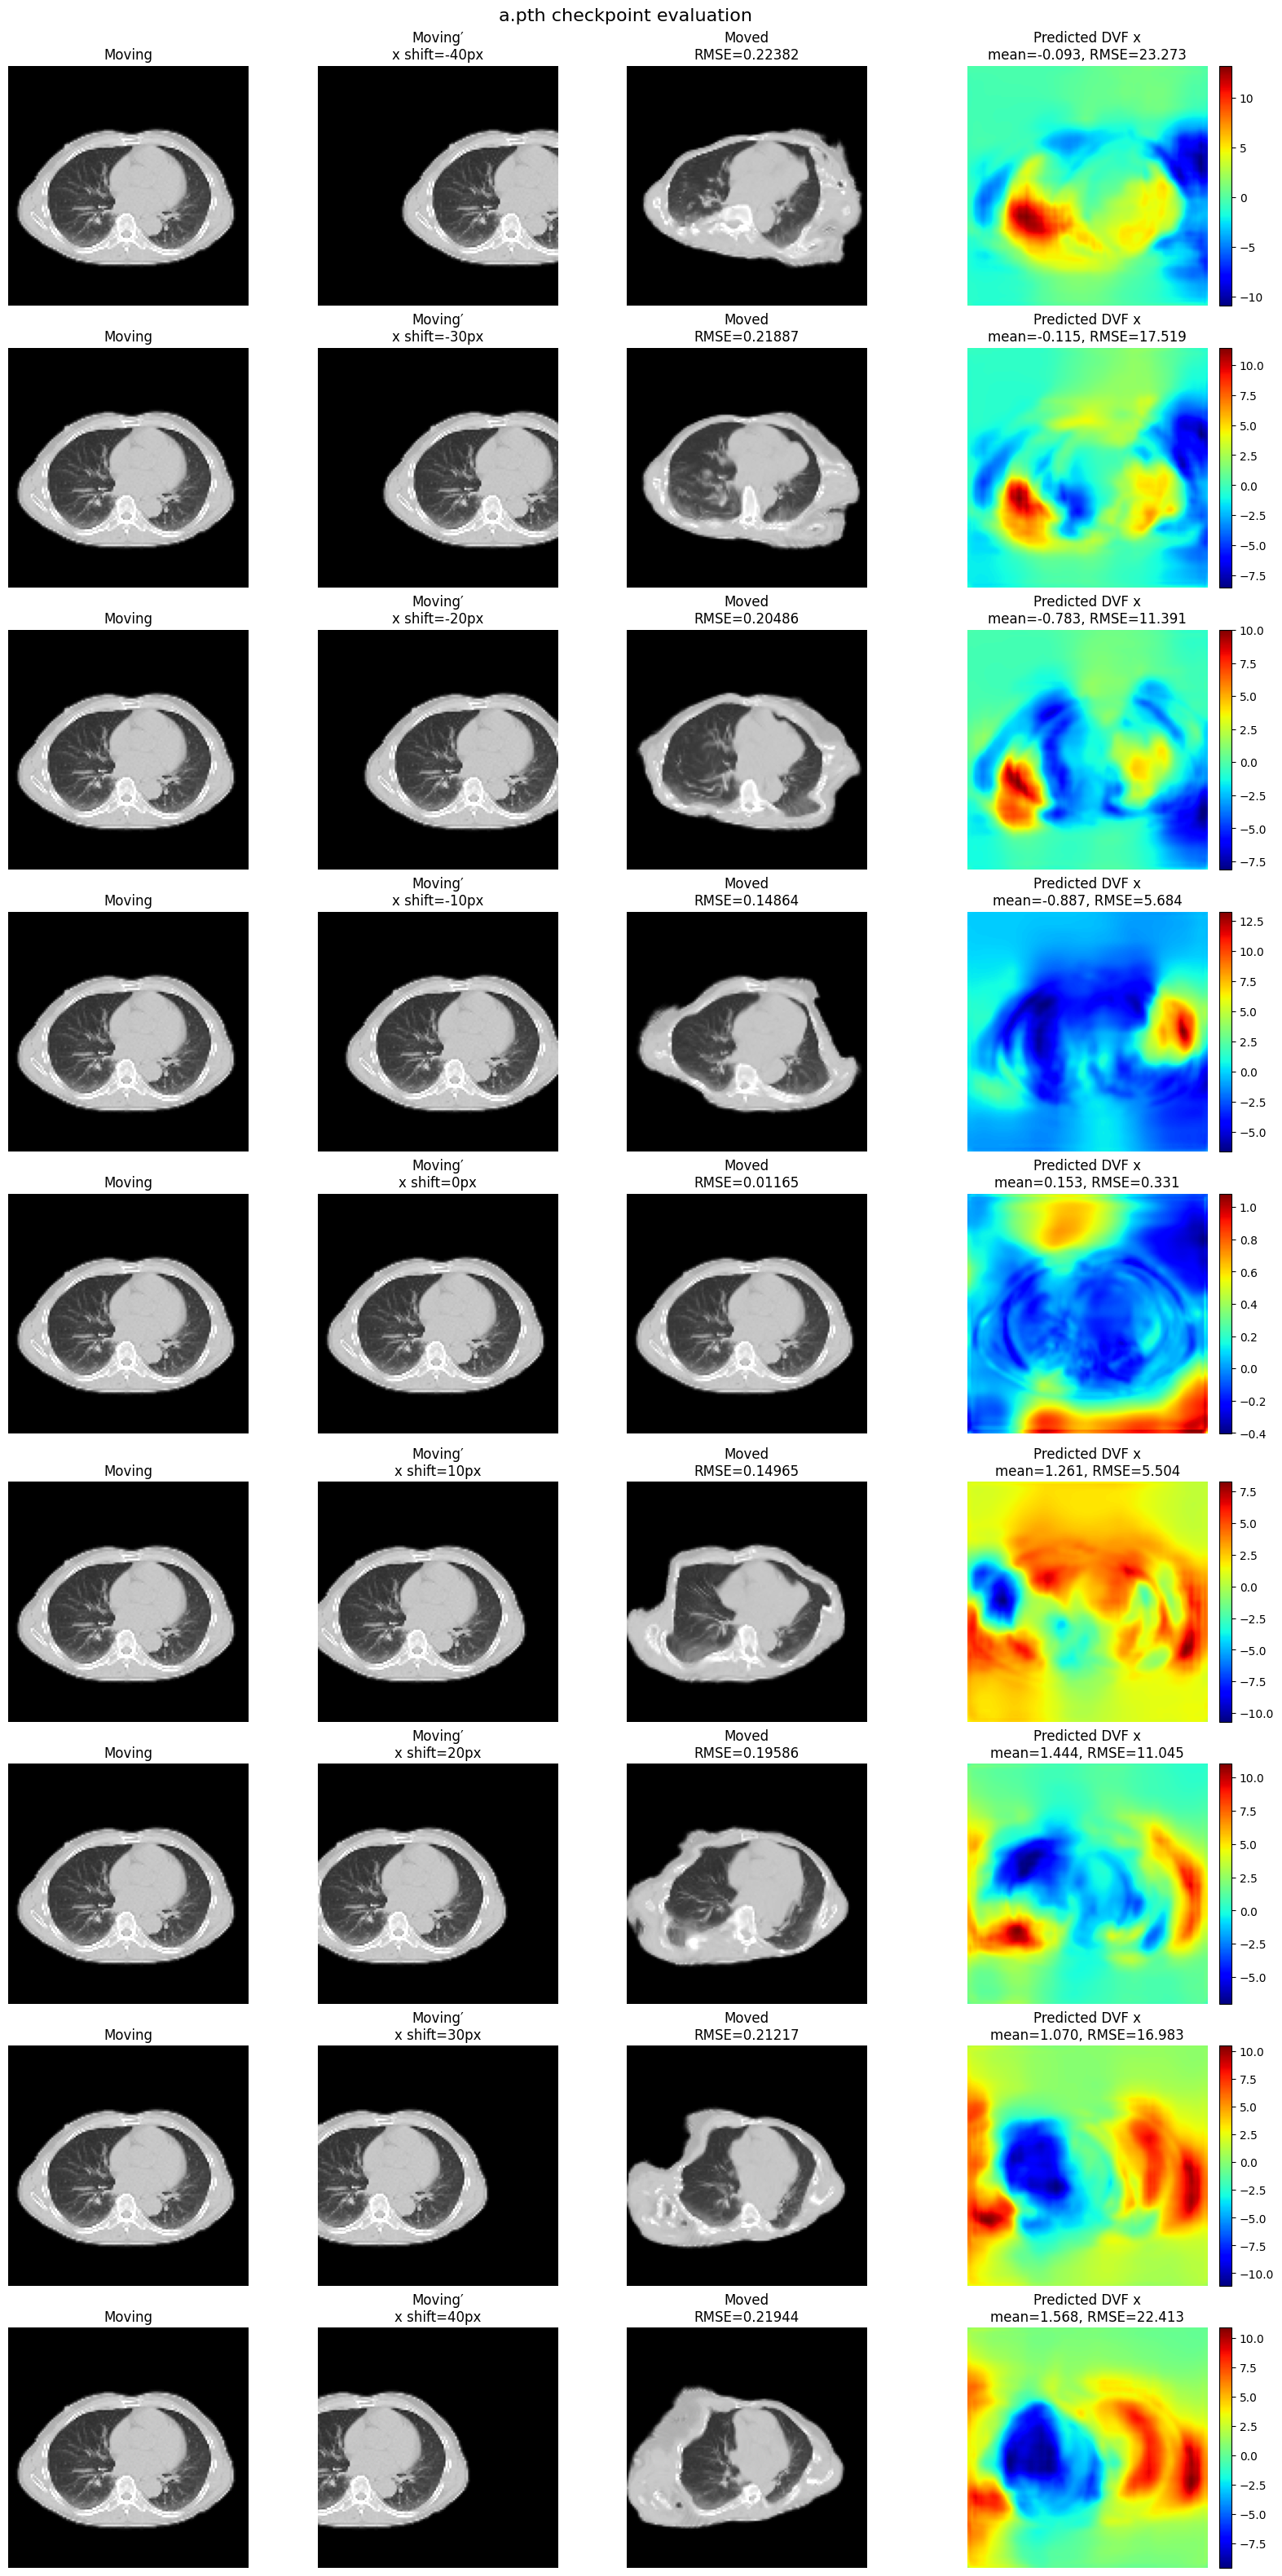

評価画像: D:\Saito\yamatoCode\a_checkpoint_evaluation\a_known_x_shifts.png
評価CSV: D:\Saito\yamatoCode\a_checkpoint_evaluation\a_known_x_shift_metrics.csv


In [2]:
# a.pth の保存済みモデルを、学習せずに固定x方向シフトで評価する
# 新しいカーネルでこのセルだけを実行できるよう、必要な設定をここで読み込む。
import os
os.environ['VXM_BACKEND'] = 'pytorch'
import csv
from pathlib import Path
import numpy as np
import scipy.ndimage
import torch
import matplotlib.pyplot as plt
import voxelmorph as vxm

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
nb_features = [[32, 64, 64, 64, 64], [64, 64, 64, 64, 64, 32, 16, 16]]
data_candidates = [Path('Data') / 'TrainData_NoBed.npz', Path('..') / 'Data' / 'TrainData_NoBed.npz']
data_path = next((path for path in data_candidates if path.exists()), None)
if data_path is None:
    raise FileNotFoundError('TrainData_NoBed.npz が見つかりません。Data または ../Data を確認してください。')
x_train = np.transpose(np.load(data_path)['Train'], (3, 0, 1, 2))
resized_shape = tuple(dim // 2 for dim in x_train.shape[1:])
x_train = np.stack([scipy.ndimage.zoom(volume, (0.5, 0.5, 0.5), order=3) for volume in x_train]).astype(np.float32)
if x_train.shape[1:] != resized_shape:
    raise ValueError(f'予期しない縮小後サイズ: {x_train.shape[1:]}')
transformer = vxm.layers.SpatialTransformer((64, 128, 128)).to(device)

checkpoint_path = Path('a.pth')
if not checkpoint_path.exists():
    raise FileNotFoundError(f'a.pth が見つかりません: {checkpoint_path.resolve()}')

evaluation_model = vxm.networks.VxmDense((64, 128, 128), nb_features, int_steps=0).to(device)
evaluation_model.load_state_dict(torch.load(checkpoint_path, map_location=device))
evaluation_model.eval()
evaluation_moving = torch.from_numpy(x_train[0:1]).unsqueeze(1).to(device, dtype=torch.float32)
evaluation_shifts = [-40, -30, -20, -10, 0, 10, 20, 30, 40]
evaluation_dir = Path('a_checkpoint_evaluation')
evaluation_dir.mkdir(exist_ok=True)
slice_index = evaluation_moving.shape[2] // 2
moving_np = evaluation_moving[0, 0, slice_index].detach().cpu().numpy()
vmin, vmax = np.percentile(moving_np, [1, 99])
rows = []

with torch.no_grad():
    fig, axes = plt.subplots(len(evaluation_shifts), 4, figsize=(16, 3.5 * len(evaluation_shifts)), constrained_layout=True)
    for row_index, shift in enumerate(evaluation_shifts):
        true_flow = torch.zeros((1, 3, *evaluation_moving.shape[2:]), device=device)
        true_flow[:, 2] = float(shift)
        target = transformer(evaluation_moving, true_flow)
        moved, predicted_flow = evaluation_model(evaluation_moving, target)
        rmse_before = torch.sqrt(torch.mean((target - evaluation_moving) ** 2)).item()
        rmse_after = torch.sqrt(torch.mean((target - moved) ** 2)).item()
        dvf_rmse = torch.sqrt(torch.mean((true_flow - predicted_flow) ** 2)).item()
        predicted_x_mean = predicted_flow[:, 2].mean().item()
        rows.append({'checkpoint': str(checkpoint_path), 'shift_pixels_x': shift, 'rmse_before': rmse_before, 'rmse_after': rmse_after, 'dvf_rmse': dvf_rmse, 'predicted_flow_x_mean': predicted_x_mean})
        panels = [(evaluation_moving, 'Moving'), (target, f"Moving′\nx shift={shift}px"), (moved, f"Moved\nRMSE={rmse_after:.5f}")]
        for column, (image, title) in enumerate(panels):
            axes[row_index, column].imshow(image[0, 0, slice_index].detach().cpu(), cmap='gray', vmin=vmin, vmax=vmax)
            axes[row_index, column].set_title(title)
            axes[row_index, column].axis('off')
        flow_image = axes[row_index, 3].imshow(predicted_flow[0, 2, slice_index].detach().cpu(), cmap='jet')
        axes[row_index, 3].set_title(f'Predicted DVF x\nmean={predicted_x_mean:.3f}, RMSE={dvf_rmse:.3f}')
        axes[row_index, 3].axis('off')
        fig.colorbar(flow_image, ax=axes[row_index, 3], fraction=0.046, pad=0.04)
    fig.suptitle('a.pth checkpoint evaluation', fontsize=16)
    figure_path = evaluation_dir / 'a_known_x_shifts.png'
    fig.savefig(figure_path, dpi=180, bbox_inches='tight')
    plt.show()
    plt.close(fig)

csv_path = evaluation_dir / 'a_known_x_shift_metrics.csv'
with csv_path.open('w', newline='', encoding='utf-8') as file:
    writer = csv.DictWriter(file, fieldnames=rows[0].keys())
    writer.writeheader()
    writer.writerows(rows)
print(f'評価画像: {figure_path.resolve()}')
print(f'評価CSV: {csv_path.resolve()}')


In [ ]:
# 1,000 epochごとの評価CSVから、128モデルの位置合わせ精度推移を描画する
import csv
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

observation_dir = Path('curriculum_observation_128model')
metrics_path = observation_dir / 'known_x_shift_metrics.csv'
if not metrics_path.exists():
    raise FileNotFoundError(
        f'評価CSVが見つかりません: {metrics_path.resolve()}。更新後の学習セルを1,000 epoch以上実行してください。'
    )

with metrics_path.open(encoding='utf-8') as file:
    raw_rows = list(csv.DictReader(file))

# 同じepoch・変位量を再評価した場合は最後の結果を採用する。
records = {}
for row in raw_rows:
    records[(int(row['epoch']), int(float(row['shift_pixels_x'])))] = row
epochs = sorted({epoch for epoch, _ in records})
display_shifts = [-40, -20, -10, 10, 20, 40]
available_shifts = [shift for shift in display_shifts if all((epoch, shift) in records for epoch in epochs)]
if not available_shifts:
    raise ValueError('全評価epochにそろって存在する変位量がありません。CSVを確認してください。')

fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
colors = plt.cm.coolwarm(np.linspace(0.05, 0.95, len(available_shifts)))
for shift, color in zip(available_shifts, colors):
    before = [float(records[(epoch, shift)]['rmse_before']) for epoch in epochs]
    after = [float(records[(epoch, shift)]['rmse_after']) for epoch in epochs]
    dvf = [float(records[(epoch, shift)]['dvf_rmse']) for epoch in epochs]
    axes[0].plot(epochs, after, color=color, linewidth=2, label=f'{shift:+d} px: after')
    axes[0].axhline(before[0], color=color, linestyle='--', linewidth=1.2, alpha=0.7)
    axes[1].plot(epochs, dvf, color=color, linewidth=2, label=f'{shift:+d} px')

axes[0].set(title='Image registration error during curriculum learning (128 model)', xlabel='Epoch', ylabel='Image RMSE')
axes[0].text(0.01, 0.98, 'Solid: after registration / Dashed: before registration', transform=axes[0].transAxes, va='top', fontsize=9)
axes[0].legend(fontsize=8, ncol=2)
axes[0].grid(alpha=0.3)
axes[1].set(title='DVF prediction error during curriculum learning (128 model)', xlabel='Epoch', ylabel='DVF RMSE (low-resolution voxels)')
axes[1].legend(fontsize=8, ncol=2)
axes[1].grid(alpha=0.3)

figure_path = observation_dir / 'rmse_learning_curve_by_shift_128model.png'
fig.savefig(figure_path, dpi=200, bbox_inches='tight')
plt.show()
plt.close(fig)
print(f'RMSE推移グラフを保存しました: {figure_path.resolve()}')
